In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.util.sampledata import DataFrame
from param import DataFrame


read data

In [2]:
df=pd.read_csv("D:/data science/data analysis/zomato/zomato_data.csv",encoding="latin1")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


CONVERT THE DATA TYPE OF RATING

In [4]:
def convert_rating(rating):
    rating=str(rating)
    rating=rating.split("/")
    rating=float(rating[0])
    return rating

df["rate"]=df["rate"].apply(convert_rating)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


DATA CLEANING
NO NULL VALUE FOUND

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'types of restaurants')

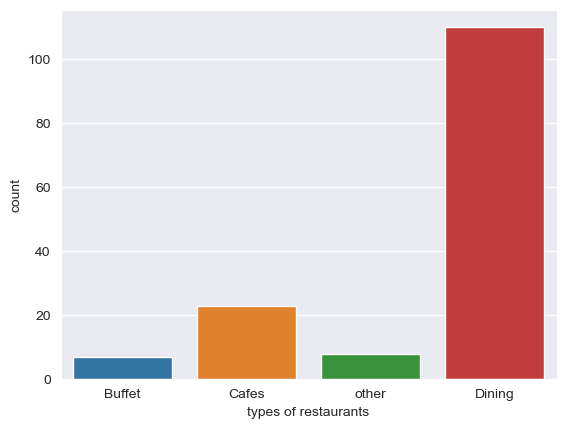

In [6]:
sns.countplot(x=df['listed_in(type)'])  # Use
plt.xlabel("types of restaurants")

Text(0.5, 0, 'restaurants')

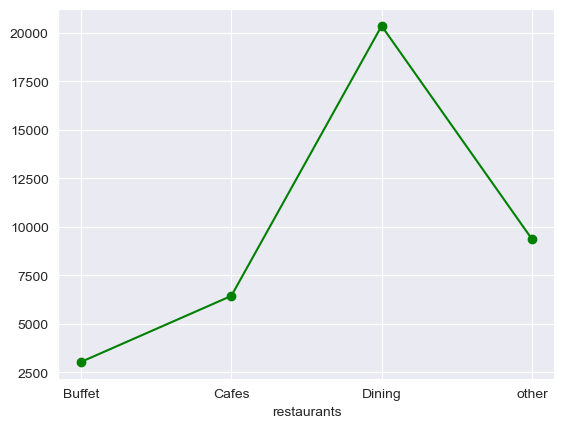

In [7]:
grouped_data=df.groupby("listed_in(type)")['votes'].sum()
grouped_data

plt.plot(grouped_data,c="green",marker="o")
plt.xlabel("restaurants")

CONCLUSION= dining restarants recived maximum votes


WHAT ARE THE RATING THAT THE MAJORITY OF RESTAURANTS HAVE RECIVED

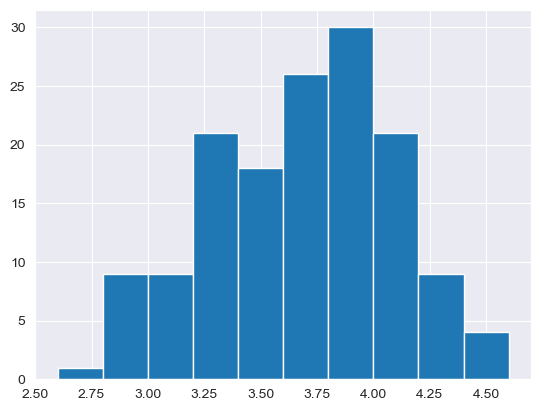

In [8]:
plt.hist(df['rate'],bins=10)
plt.show()

300

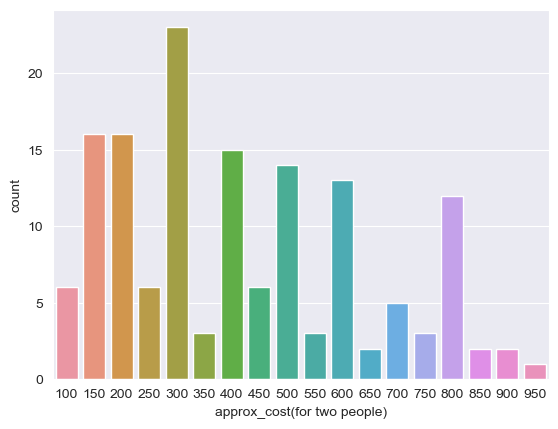

In [9]:
coupled_data=df['approx_cost(for two people)']
sns.countplot(x=coupled_data)
df['approx_cost(for two people)'].mode()[0]

**conslusion= couple spend approx 300 ruppes for a order maximum times**

**ques** which mode recives more rating

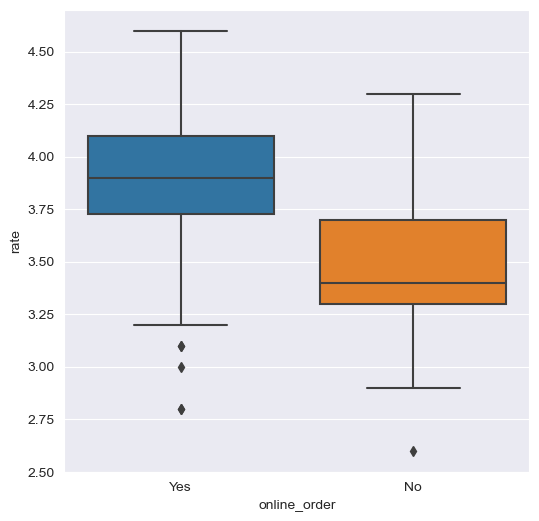

4

In [10]:
plt.figure(figsize=(6,6))
sns.boxplot(x= 'online_order',y='rate',data=df)
plt.show()
4

**Question : ** which type of restaurants recives more offiline order

In [11]:
pivot=pd.pivot_table(df,index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
print(pivot)


online_order     No  Yes
listed_in(type)         
Buffet            3    4
Cafes             8   15
Dining           77   33
other             2    6


<Axes: xlabel='online_order', ylabel='listed_in(type)'>

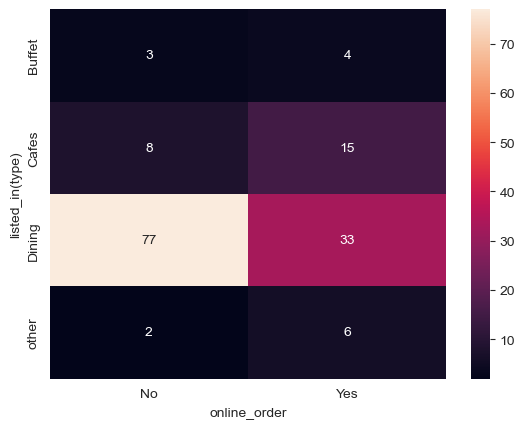

In [12]:
sns.heatmap(pivot,annot=True)

